In [41]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

# Generate Random Numbers 

In [42]:
rng = np.random.default_rng(42)

# define employees, Departments, regions 

In [43]:
employees = ['Ali', 'yaseen', 'Ahed', 'Ghaydaa', 'Dana', 'Mohd', 'Hiba', 'Marina', 'Ammal','Amal', 'Mona', 'Sama']   

In [87]:
departments = ['IndoorSales', 'OutdoorSales', 'Marketing', 'IndoorSales', 'OutdoorSales', 'Marketing', 'Marketing', 'OutdoorSales', 'IndoorSales', 'IndoorSales', 'IndoorSales', 'IndoorSales']

In [88]:
regions = ['North', 'South', 'East', 'West', 'South', 'East', 'West', 'South', 'East', 'West', 'North', 'North']

# Months

In [89]:
months = pd.date_range('2026-01-01', periods=6, freq='MS')
months

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01'],
              dtype='datetime64[ns]', freq='MS')

# Build rows

In [90]:
rows = [] 
for employee, department, region in zip (employees, departments, regions): 
    base_sale = rng.integers(5000 , 18500)
    for month in months :
        sales = int(base_sale + rng.integers(-500,1000) ) 
        target = int(sales + rng.integers(-250,760) ) 
        rows.append([employee, department, region, month, sales, target])
    
    

In [91]:
df = pd.DataFrame(rows, columns =['Employee', 'Department', 'Region', 'Month', 'Sales', 'Target'])

In [92]:
df.head(6)

,Employee,Department,Region,Month,Sales,Target
0,Ali,IndoorSales,North,2026-01-01,6525,6521
1,Ali,IndoorSales,North,2026-02-01,7093,7580
2,Ali,IndoorSales,North,2026-03-01,7194,7892
3,Ali,IndoorSales,North,2026-04-01,7256,7329
4,Ali,IndoorSales,North,2026-05-01,6265,6635
5,Ali,IndoorSales,North,2026-06-01,7478,8212


In [93]:
df.tail(2)

,Employee,Department,Region,Month,Sales,Target
70,Sama,IndoorSales,North,2026-05-01,12004,12729
71,Sama,IndoorSales,North,2026-06-01,12243,12595


# calculate columns : 1- If target is acheived or not 

In [94]:
df['TragetAcheived'] = df['Sales']>df['Target']

In [95]:
df.head(2)

,Employee,Department,Region,Month,Sales,Target,TragetAcheived
0,Ali,IndoorSales,North,2026-01-01,6525,6521,True
1,Ali,IndoorSales,North,2026-02-01,7093,7580,False


# 2- Performance of the employee based on how close they are to the Target : 
Sales / target

In [96]:
df['PerformanceRatio']= df['Sales']/df['Target']
df.head(2)

,Employee,Department,Region,Month,Sales,Target,TragetAcheived,PerformanceRatio
0,Ali,IndoorSales,North,2026-01-01,6525,6521,True,1.000613
1,Ali,IndoorSales,North,2026-02-01,7093,7580,False,0.935752


# Gap between Sales and the target : sales - target ( difference ) 

In [97]:
df['TargetGap']=df['Sales']-df['Target']
df.head(2)

,Employee,Department,Region,Month,Sales,Target,TragetAcheived,PerformanceRatio,TargetGap
0,Ali,IndoorSales,North,2026-01-01,6525,6521,True,1.000613,4
1,Ali,IndoorSales,North,2026-02-01,7093,7580,False,0.935752,-487


# Summary dataframe ( Table) based on the sale & department 

In [98]:
Dept_summary = df.groupby('Department').agg(
    AvgSale = ('Sales', 'mean'),
    SumSale = ('Sales', 'sum'),
    SumTarget = ( 'Target', 'sum'), 
    CountTarget = ( 'Target', 'count'), 
    Records = ('Employee', 'count') ) 



In [99]:
Dept_summary.sort_values('SumSale', ascending= True)

,AvgSale,SumSale,SumTarget,CountTarget,Records
Department,,,,,
OutdoorSales,11074.166667,199335,202378,18,18
Marketing,12829.833333,230937,235667,18,18
IndoorSales,10950.055556,394202,406243,36,36


# Summary dataframe ( Table) based on the sale & Region  

In [100]:
Region_summary = df.groupby('Region').agg(
    AvgSale = ('Sales', 'mean'),
    SumSale = ('Sales', 'sum'),
    SumTarget = ( 'Target', 'sum'), 
    CountTarget = ( 'Target', 'count'), 
    Records = ('Employee', 'count') ) .sort_values('SumSale', ascending= True)
Region_summary 

,AvgSale,SumSale,SumTarget,CountTarget,Records
Region,,,,,
North,8913.555556,160444,166119,18,18
South,11074.166667,199335,202378,18,18
West,11987.388889,215773,221569,18,18
East,13829.000000,248922,254222,18,18


# monthly trend by sales

In [101]:
monthly_trend = df.groupby('Month')['Sales'].sum()
monthly_trend 

Month
2026-01-01    135196
2026-02-01    138290
2026-03-01    141327
2026-04-01    135921
2026-05-01    135802
2026-06-01    137938
Name: Sales, dtype: int64

# Visualiza OF summary Tables 

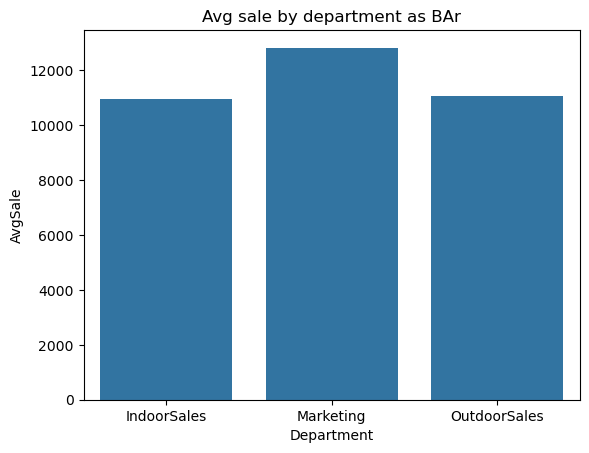

In [102]:
sns.barplot(x=Dept_summary.index, y=Dept_summary['AvgSale'])
plt.title("Avg sale by department as BAr")  # Use plt.title instead of matplotlib.title
plt.show()

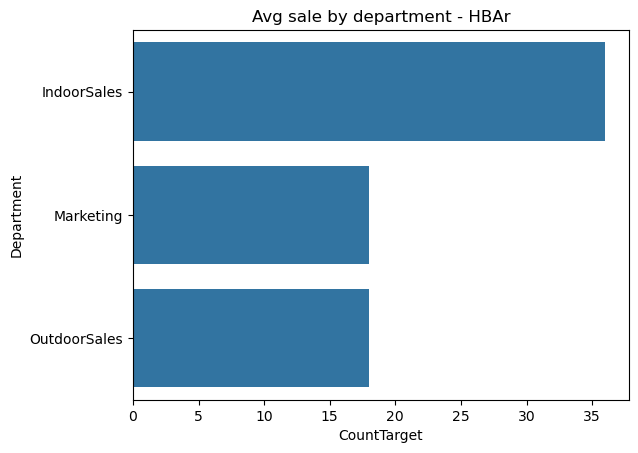

In [103]:
sns.barplot(x=Dept_summary['CountTarget'], y=Dept_summary.index)
plt.title("Avg sale by department - HBAr")  # Use plt.title instead of matplotlib.title
plt.show()

# MOnthly Trend 

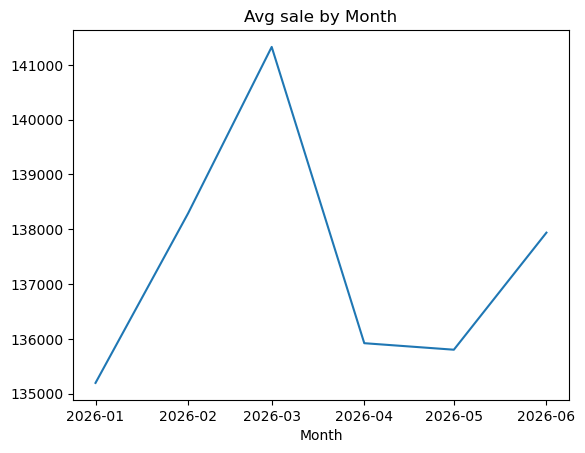

In [104]:
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values)
plt.title("Avg sale by Month")  # Use plt.title instead of matplotlib.title
plt.show()

In [ ]:
# summary ( 